# Plot posterior parameter estimates

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from devreact import figures
from devreact import model

model_name = 'neural-dual-v6'

signal_names = ['vlpfc', 'prec', 'ang', 'lpc', 'hpc', 'phc']
roi_names = ['VLPFC', 'Precuneus', 'Angular gyrus', 'IPS/SPL', 'Hippocampus', 'PHC']

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name
fig_dir.mkdir(parents=True, exist_ok=True)

%matplotlib inline
figures.set_style()

In [2]:
trace = az.from_netcdf(fig_dir / 'trace.nc')

## Create table of group-level parameters

In [3]:
param_map = {
    "τ": r"$\tau$",
    "A": r"$A$",
    "b_b0": r"$b_{\beta0}$",
    "b_b1": r"$b_{\beta1}$",
    "b_σ": r"$\sigma_b$",
    "v2_b0": r"$v_{1,\beta0}$",
    "v2_b1": r"$v_{1,\beta1}$",
    "v2_σ": r"$\sigma_1$",
    "v1_b0": r"$v_{2,\beta0}$",
    "v1_b1": r"$v_{2,\beta1}$",
    "v1_σ": r"$\sigma_2$",
    "r": "$r$",
    "v3_b0": r"$v_{3,\beta0}$",
    "v3_b1": r"$v_{3,\beta1}$",
    "v3_σ": r"$\sigma_3$",
    "v4_b0": r"$v_{4,\beta0}$",
    "v4_b1": r"$v_{4,\beta1}$",
    "v4_σ": r"$\sigma_4$",
}

tab = model.parameter_table(trace, param_map)
tab.to_latex(fig_dir / 'group_param.tex', escape=False, index=False)
tab

/var/folders/9d/zh72ny012k7bvgr427k05d8w0000gn/T/ipykernel_12623/2797541017.py:23: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tab.to_latex(fig_dir / 'group_param.tex', escape=False, index=False)


,Parameter,Mean,94\% HDI
0,$\tau$,0.007374,"[0.0000, 0.0207]"
1,$A$,5.885500,"[5.2956, 6.4628]"
2,$b_{\beta0}$,2.396669,"[2.3335, 2.4591]"
3,$b_{\beta1}$,0.001998,"[-0.0006, 0.0046]"
4,$\sigma_b$,0.084855,"[0.0677, 0.1026]"
5,"$v_{1,\beta0}$",4.009550,"[3.7379, 4.2881]"
6,"$v_{1,\beta1}$",0.104273,"[0.0759, 0.1318]"
7,$\sigma_1$,1.003727,"[0.8190, 1.1894]"
8,"$v_{2,\beta0}$",1.457313,"[1.1169, 1.7812]"
9,"$v_{2,\beta1}$",0.054965,"[0.0300, 0.0802]"


## Create table of slope parameters

In [4]:
slope_vars = [
    f'{param}_{signal}_{coef}'
    for param in ['v2', 'v1'] 
    for signal in signal_names 
    for coef in ['b0', 'b1']
]
slope_code = [
    f'$v_{{{a},\\mathrm{{{signal}}},\\beta{coef}}}$'
    for a in [1, 2]
    for signal in signal_names
    for coef in [0, 1]
]

slope_map = dict(zip(slope_vars, slope_code))
tab = model.parameter_table(trace, slope_map)
tab.to_latex(fig_dir / 'group_slope_param.tex', escape=False, index=False)
tab

/var/folders/9d/zh72ny012k7bvgr427k05d8w0000gn/T/ipykernel_12623/494913585.py:16: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tab.to_latex(fig_dir / 'group_slope_param.tex', escape=False, index=False)


,Parameter,Mean,94\% HDI
0,"$v_{1,\mathrm{vlpfc},\beta0}$",-0.260361,"[-0.3414, -0.1804]"
1,"$v_{1,\mathrm{vlpfc},\beta1}$",0.000036,"[-0.0104, 0.0102]"
2,"$v_{1,\mathrm{prec},\beta0}$",0.004809,"[-0.0729, 0.0831]"
3,"$v_{1,\mathrm{prec},\beta1}$",0.009440,"[0.0003, 0.0190]"
4,"$v_{1,\mathrm{ang},\beta0}$",0.128468,"[0.0400, 0.2209]"
5,"$v_{1,\mathrm{ang},\beta1}$",-0.015552,"[-0.0272, -0.0046]"
6,"$v_{1,\mathrm{lpc},\beta0}$",-0.225152,"[-0.3105, -0.1387]"
7,"$v_{1,\mathrm{lpc},\beta1}$",-0.009469,"[-0.0205, 0.0019]"
8,"$v_{1,\mathrm{hpc},\beta0}$",0.115670,"[0.0569, 0.1758]"
9,"$v_{1,\mathrm{hpc},\beta1}$",0.002171,"[-0.0049, 0.0090]"


## Create table of standard deviation parameters

In [5]:
sigma_vars = [
    f'{param}_{signal}_σ'
    for param in ['v2', 'v1'] 
    for signal in signal_names 
]
sigma_code = [
    f'$\\sigma_{{{a},\\mathrm{{{signal}}}}}$'
    for a in [1, 2]
    for signal in signal_names
]
sigma_map = dict(zip(sigma_vars, sigma_code))
tab = model.parameter_table(trace, sigma_map)
tab.to_latex(fig_dir / 'group_sigma_param.tex', escape=False, index=False)
tab

/var/folders/9d/zh72ny012k7bvgr427k05d8w0000gn/T/ipykernel_12623/1253415783.py:13: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tab.to_latex(fig_dir / 'group_sigma_param.tex', escape=False, index=False)


,Parameter,Mean,94\% HDI
0,"$\sigma_{1,\mathrm{vlpfc}}$",0.160560,"[0.0731, 0.2523]"
1,"$\sigma_{1,\mathrm{prec}}$",0.101918,"[0.0002, 0.1853]"
2,"$\sigma_{1,\mathrm{ang}}$",0.166895,"[0.0695, 0.2616]"
3,"$\sigma_{1,\mathrm{lpc}}$",0.129589,"[0.0149, 0.2228]"
4,"$\sigma_{1,\mathrm{hpc}}$",0.110995,"[0.0191, 0.1857]"
5,"$\sigma_{1,\mathrm{phc}}$",0.071605,"[0.0000, 0.1369]"
6,"$\sigma_{2,\mathrm{vlpfc}}$",0.129686,"[0.0002, 0.2721]"
7,"$\sigma_{2,\mathrm{prec}}$",0.242956,"[0.0062, 0.4175]"
8,"$\sigma_{2,\mathrm{ang}}$",0.447571,"[0.2494, 0.6547]"
9,"$\sigma_{2,\mathrm{lpc}}$",0.425354,"[0.2491, 0.6135]"


## Participant drift rate intercepts

In [6]:
# range of ages to get estimates for
ages = np.arange(6, 34, .1)
age_ticks = np.arange(5, 36, 5)
age_lim = np.array([5, 35])

In [7]:
figsize = (5, 5)
ylim = (-1, 8)

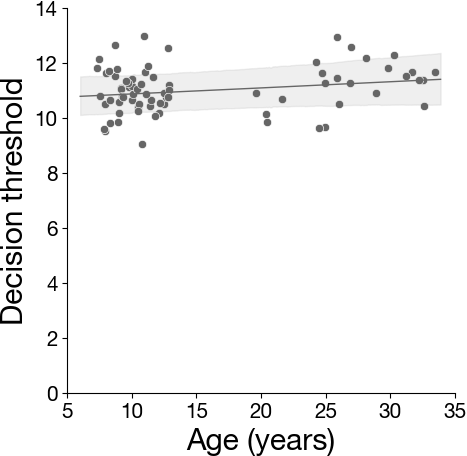

In [8]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(
    trace, 'b', ages, age_ticks, ax=ax, color=(.4, .4, .4), log=True
)
ax.set(ylabel='Decision threshold', ylim=(0, 14))
figures.savefig(fig, fig_dir / 'b.pdf')

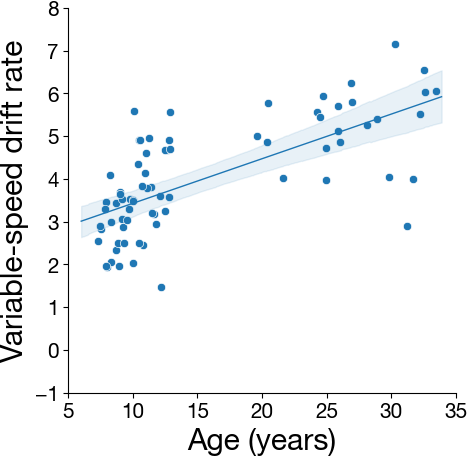

In [9]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2', ages, age_ticks, ax=ax)
ax.set(ylabel='Variable-speed drift rate', ylim=ylim)
figures.savefig(fig, fig_dir / 'v2.pdf')

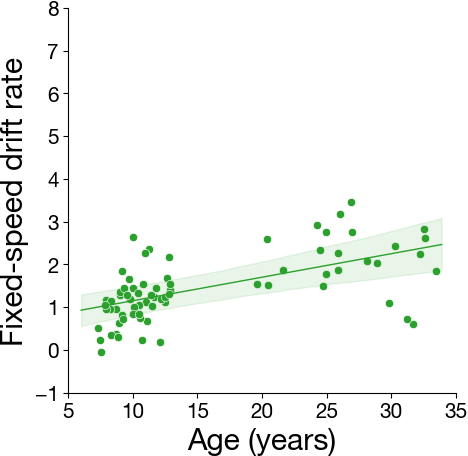

In [10]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1', ages, age_ticks, color='C2', ax=ax)
ax.set(ylabel='Fixed-speed drift rate', ylim=ylim)
figures.savefig(fig, fig_dir / 'v1.pdf')

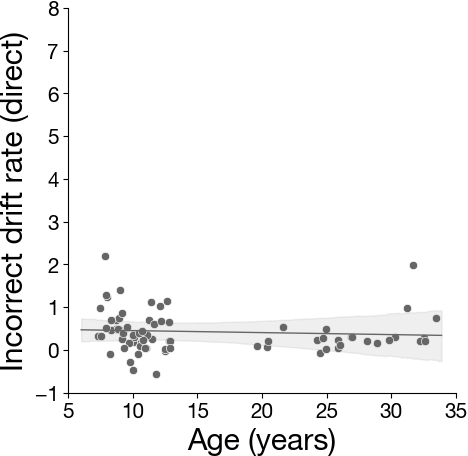

In [11]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v3', ages, age_ticks, color=(0.4, 0.4, 0.4), ax=ax)
ax.set(ylabel='Incorrect drift rate (direct)', ylim=ylim)
figures.savefig(fig, fig_dir / 'v3.pdf')

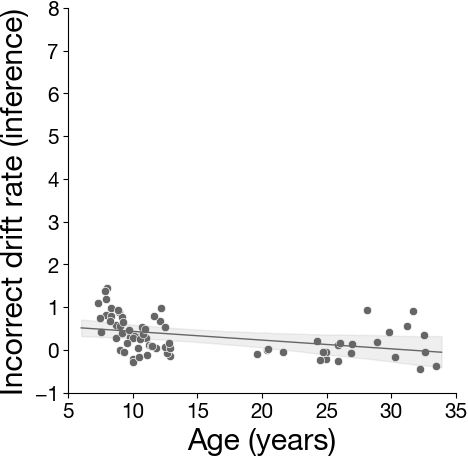

In [12]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v4', ages, age_ticks, color=(0.4, 0.4, 0.4), ax=ax)
ax.set(ylabel='Incorrect drift rate (inference)', ylim=ylim)
figures.savefig(fig, fig_dir / 'v4.pdf')

## Neural drift rate slope parameters

In [13]:
figsize = (6.5, 6.5)

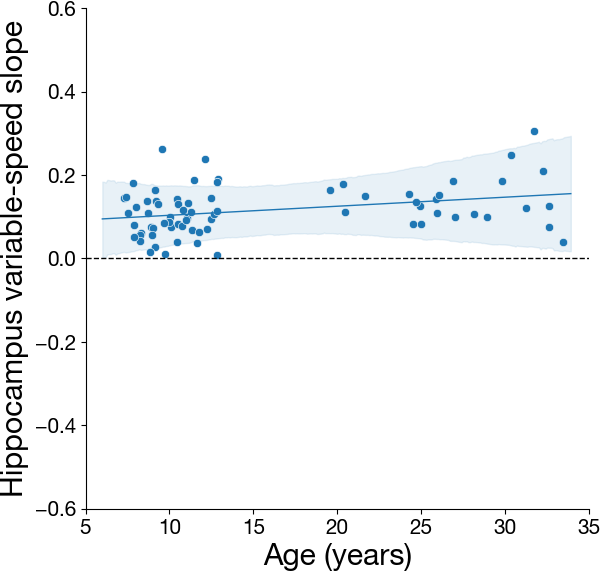

In [14]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2_hpc', ages, age_ticks, absmax=0.6, ax=ax)
ax.set(ylabel='Hippocampus variable-speed slope', yticks=np.arange(-.6, .61, .2))
figures.savefig(fig, fig_dir / 'slope_hpc_v2.pdf')

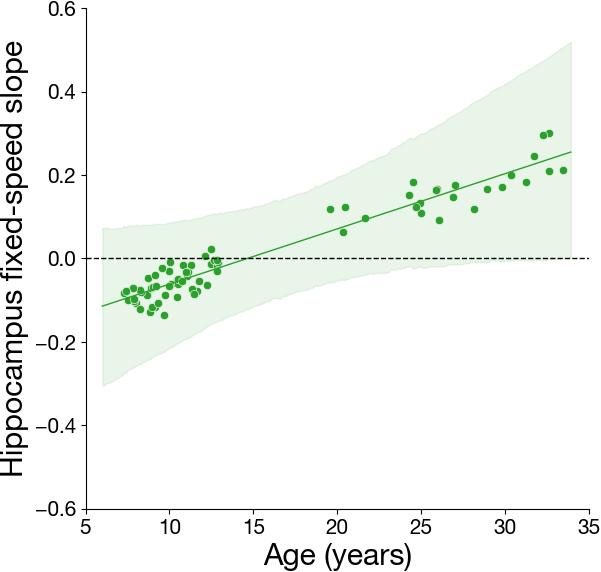

In [15]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1_hpc', ages, age_ticks, absmax=0.6, color='C2', ax=ax)
ax.set(ylabel='Hippocampus fixed-speed slope', yticks=np.arange(-.6, .61, .2))
figures.savefig(fig, fig_dir / 'slope_hpc_v1.pdf')

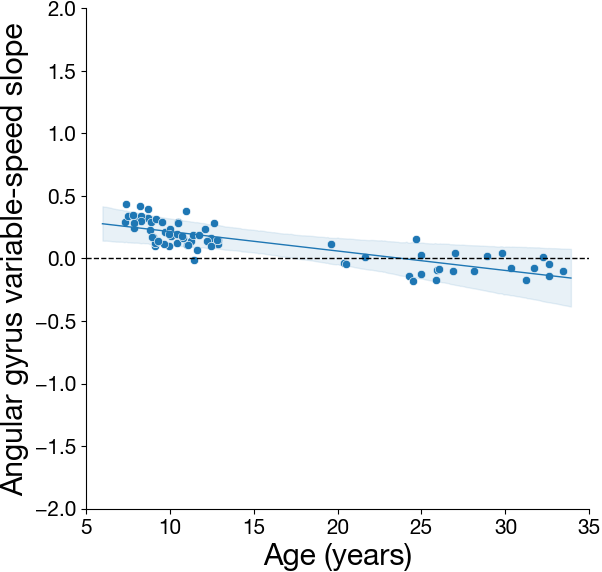

In [16]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2_ang', ages, age_ticks, absmax=2, ax=ax)
ax.set(ylabel='Angular gyrus variable-speed slope', yticks=np.arange(-2, 2.01, .5))
figures.savefig(fig, fig_dir / 'slope_ang_v2.pdf')

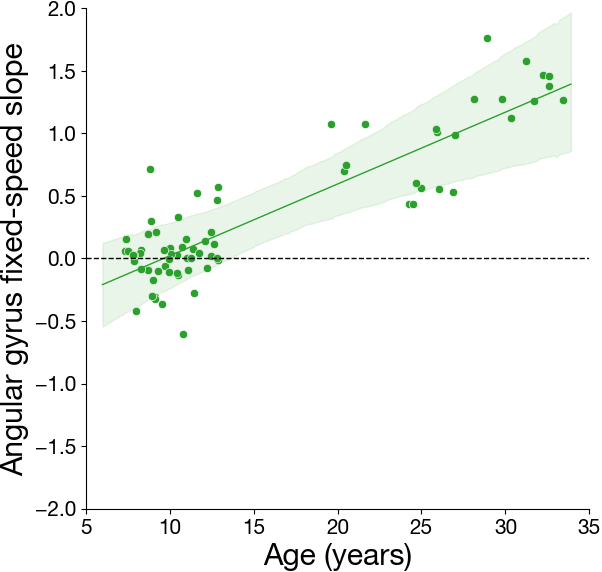

In [17]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1_ang', ages, age_ticks, absmax=2, color='C2', ax=ax)
ax.set(ylabel='Angular gyrus fixed-speed slope', yticks=np.arange(-2, 2.01, .5))
figures.savefig(fig, fig_dir / 'slope_ang_v1.pdf')

## Neural signal slope

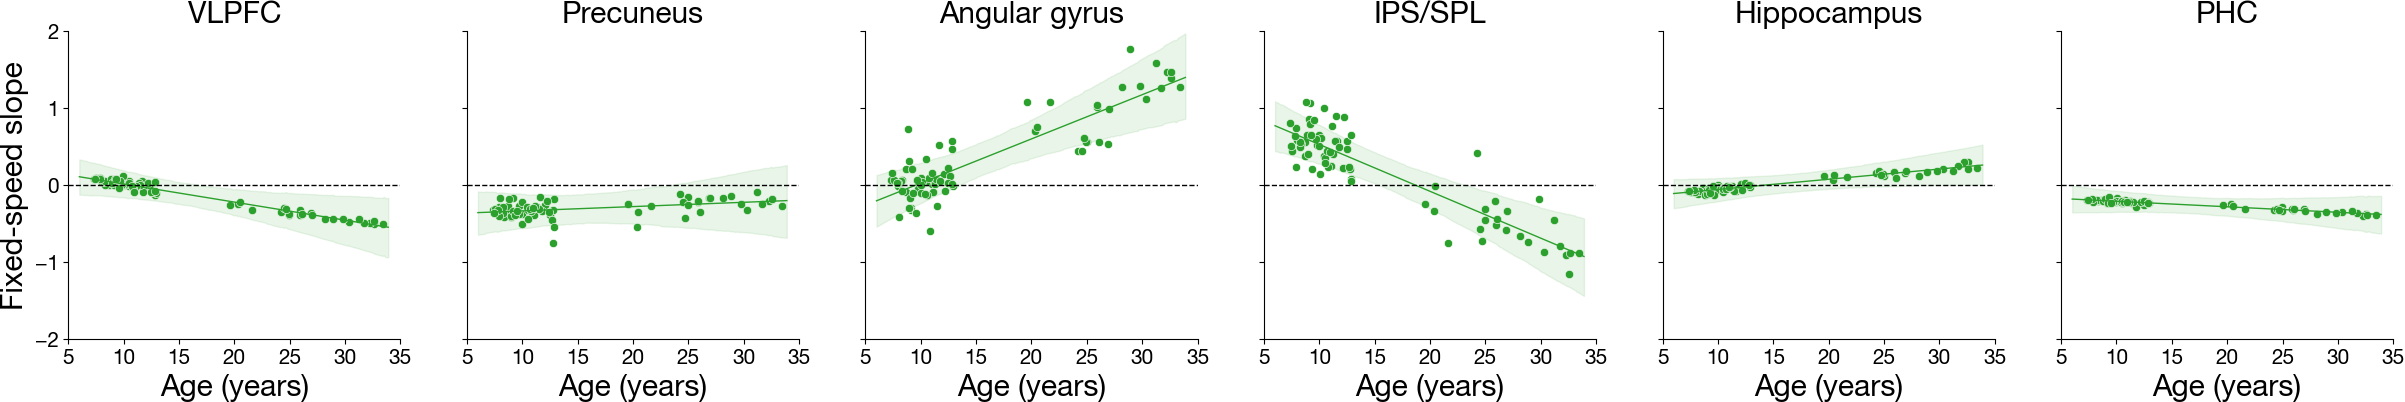

In [18]:
param_name = 'v1'
fig, ax = figures.plot_signal_slopes(
    trace, param_name, signal_names, roi_names, ages=ages, age_ticks=age_ticks, color='C2', absmax=2
)
ax[0].set_ylabel('Fixed-speed slope')
figures.savefig(fig, fig_dir / f'slope_{param_name}.pdf')

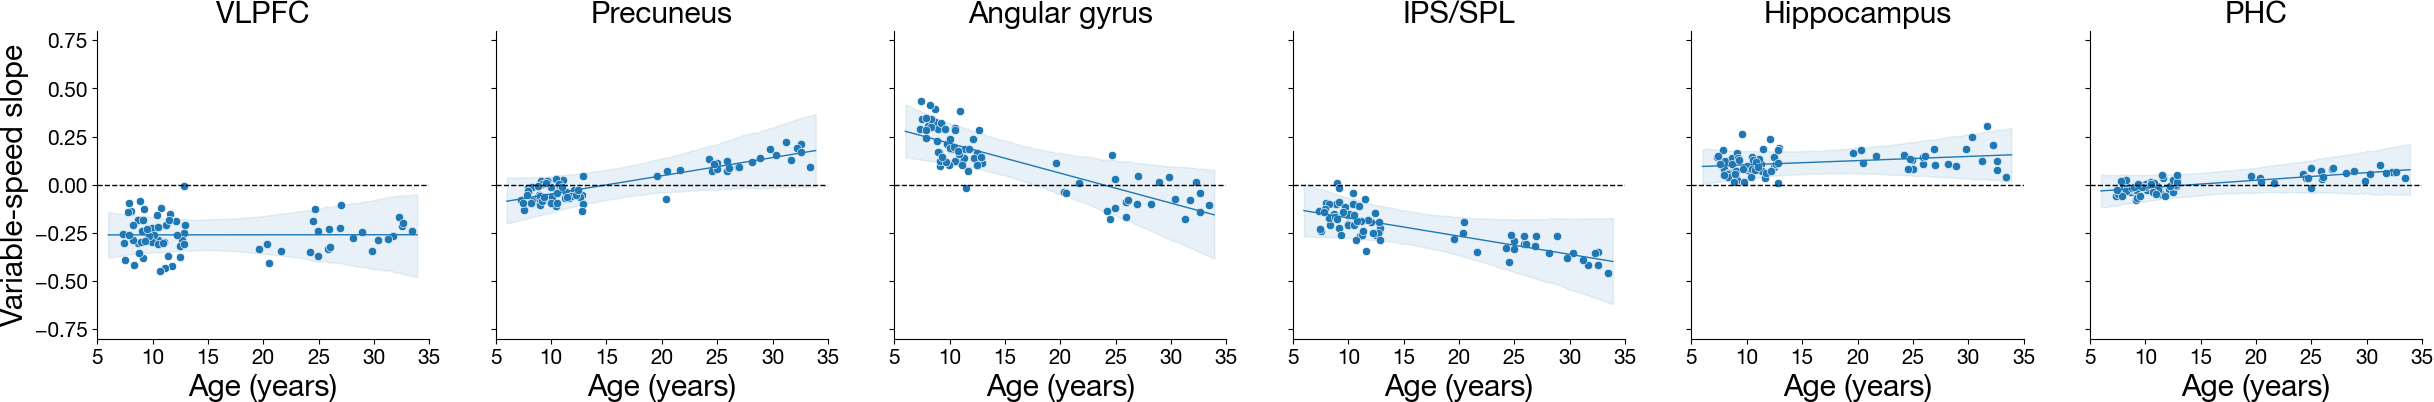

In [19]:
param_name = 'v2'
fig, ax = figures.plot_signal_slopes(
    trace, param_name, signal_names, roi_names, ages=ages, age_ticks=age_ticks, absmax=.8
)
ax[0].set_ylabel('Variable-speed slope')
figures.savefig(fig, fig_dir / f'slope_{param_name}.pdf')

## Neural signal slope age coefficients

In [20]:
coef_vars = ['b0', 'b1']
coef_labels = ['Intercept', 'Slope']

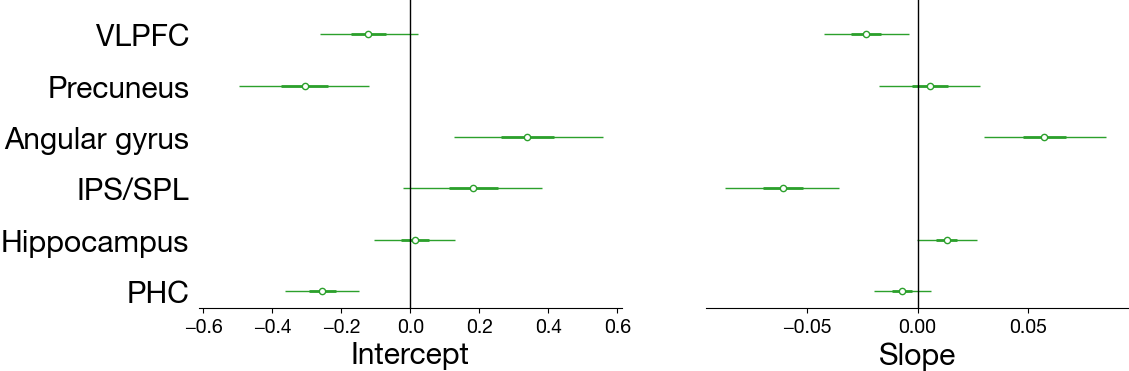

In [21]:
param_name = 'v1'
fig, ax = figures.plot_signal_coef(
    trace, coef_vars, param_name, signal_names, coef_labels, roi_names, colors=['C2']
)
figures.savefig(fig, fig_dir / f'slope_coef_{param_name}.pdf')

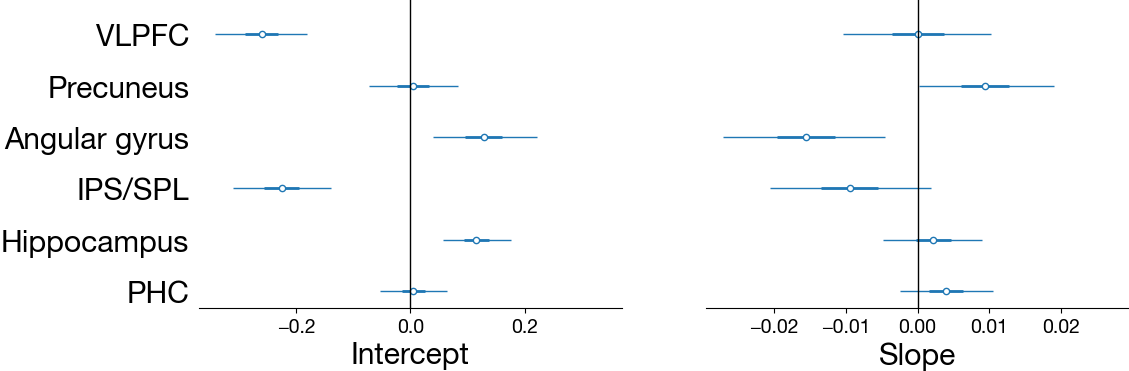

In [22]:
param_name = 'v2'
fig, ax = figures.plot_signal_coef(
    trace, coef_vars, param_name, signal_names, coef_labels, roi_names
)
figures.savefig(fig, fig_dir / f'slope_coef_{param_name}.pdf')

In [23]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.5
IPython version      : 8.5.0

numpy     : 1.21.6
seaborn   : 0.11.2
devreact  : 0.1.0
matplotlib: 3.6.0
arviz     : 0.12.1
pandas    : 1.5.0

